In [1]:
# ===============================
# Step 1: Import Required Libraries
# ===============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# ===============================
# Step 2: Load Dataset
# ===============================

housing = fetch_california_housing()

X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

print("Dataset shape:", X.shape)
X.head()

Dataset shape: (20640, 8)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [3]:
# ===============================
# Step 3: Train-Test Split
# ===============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16512, 8)
Testing data: (4128, 8)


In [4]:
# ===============================
# Step 4: Feature Scaling
# ===============================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
# ===============================
# Step 5: Baseline Model (Linear Regression)
# ===============================


lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression R2:", lr_r2)

Linear Regression RMSE: 0.7455813830127763
Linear Regression R2: 0.575787706032451


In [6]:
# ===============================
# Step 6: Decision Tree Model
# ===============================

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train_scaled, y_train)

dt_pred = dt_model.predict(X_test_scaled)

dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree RMSE:", dt_rmse)
print("Decision Tree R2:", dt_r2)

Decision Tree RMSE: 0.7028289572288925
Decision Tree R2: 0.6230424613065773


In [7]:
# ===============================
# Step 7: Cross-Validation (Model Validation)
# ===============================

cv_scores = cross_val_score(
    dt_model,
    X_train_scaled,
    y_train,
    scoring="neg_mean_squared_error",
    cv=5
)

rmse_scores = np.sqrt(-cv_scores)

print("Cross Validation RMSE Scores:", rmse_scores)
print("Average RMSE:", rmse_scores.mean())

Cross Validation RMSE Scores: [0.75572899 0.73265968 0.70292795 0.72643393 0.70331834]
Average RMSE: 0.724213776329786


In [8]:
# ===============================
# Step 8: Hyperparameter Tuning using GridSearchCV
# ==============================

param_grid = {
    "max_depth": [3,5,10,None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [10]:
# ===============================
# Step 9: Train Best Model
# ==============================


best_model = grid_search.best_estimator_

best_pred = best_model.predict(X_test_scaled)

best_rmse = np.sqrt(mean_squared_error(y_test, best_pred))
best_r2 = r2_score(y_test, best_pred)

print("Tuned Model RMSE:", best_rmse)
print("Tuned Model R2:", best_r2)

Tuned Model RMSE: 0.6387361927912558
Tuned Model R2: 0.6886590898292316


In [11]:
# ===============================
# Step 10: Model Comparison
# ==============================

results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Tuned Decision Tree"],
    "RMSE": [lr_rmse, dt_rmse, best_rmse],
    "R2 Score": [lr_r2, dt_r2, best_r2]
})

print(results)

                 Model      RMSE  R2 Score
0    Linear Regression  0.745581  0.575788
1        Decision Tree  0.702829  0.623042
2  Tuned Decision Tree  0.638736  0.688659


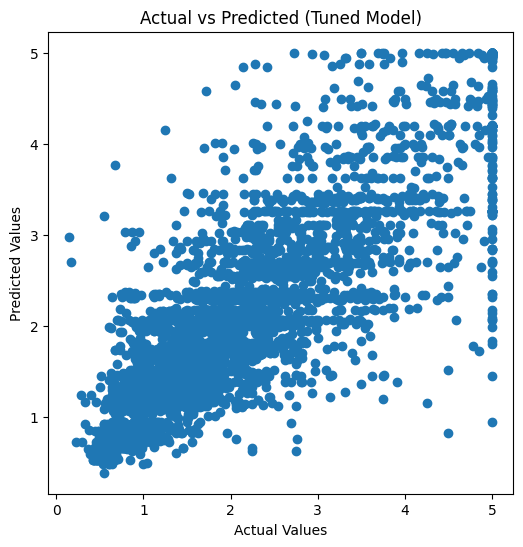

In [12]:
# ===============================
# Step 11: Actual vs Predicted Plot
# ==============================

plt.figure(figsize=(6,6))

plt.scatter(y_test, best_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted (Tuned Model)")

plt.show()

In [13]:
# ===============================
# Step 12: Overfitting Check
# ==============================

train_pred = best_model.predict(X_train_scaled)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, best_pred))

print("Training RMSE:", train_rmse)
print("Testing RMSE:", test_rmse)

Training RMSE: 0.4865960136384907
Testing RMSE: 0.6387361927912558
